In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import netCDF4
import string

import numpy as np
import xarray as xr
from scipy.spatial import cKDTree
from datetime import timedelta
import gsw
import ArcTools as Atools
import pandas as pd

# TEMP

In [2]:
ds_anom = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_relative_ISAS_barents_full.nc',decode_times=False)

In [3]:
ds_anom

<xarray.Dataset>
Dimensions:              (profile: 88090, depth: 187)
Coordinates:
  * profile              (profile) int64 0 3 4 5 ... 319673 319677 319678 319679
  * depth                (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon                  (profile) float64 ...
    lat                  (profile) float64 ...
Data variables:
    longitude            (profile) float64 ...
    latitude             (profile) float64 ...
    time                 (profile) float64 ...
    source               (profile) object ...
    dataset_index        (profile) float64 ...
    is_duplicate         (profile) float64 ...
    temperature          (profile, depth) float64 ...
    sum_temperature      (profile) float64 ...
    sum_depth            (profile) float64 ...
    nb_depth             (profile) float64 ...
    temperature_QC       (profile, depth) float64 ...
    temperature_QC_anom  (profile, depth) float64 ...
Attributes:
    title:        ARGO temperature profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

# Load boxes

In [4]:

boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
                   boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
                   boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
box_id = np.array(boxes["Box ID"].values)

In [5]:
from matplotlib.path import Path
import numpy as np

profiles_in_box = {}

for i in range(len(xc150)):

    # build polygon for the box
    polygon = np.column_stack((xc150[i], yc150[i]))
    path = Path(polygon)

    # combine profile coordinates
    points = np.column_stack((ds_anom.longitude.values, ds_anom.latitude.values))

    # test which profiles fall inside
    inside = path.contains_points(points)

    # store indices of profiles inside the box
    profiles_in_box[box_id[i]] = np.where(inside)[0]
    if len(profiles_in_box[box_id[i]])>0:
        print(f"Box {box_id[i]}: {len(profiles_in_box[box_id[i]])} profiles inside")
counts = [len(profiles_in_box[box_id[i]]) for i in range(len(box_id))]


Box 90: 9 profiles inside
Box 91: 8 profiles inside
Box 92: 24 profiles inside
Box 131: 249 profiles inside
Box 132: 1323 profiles inside
Box 133: 10036 profiles inside
Box 134: 3587 profiles inside
Box 136: 21 profiles inside
Box 137: 79 profiles inside
Box 138: 16 profiles inside
Box 139: 7 profiles inside
Box 140: 1 profiles inside
Box 142: 5 profiles inside
Box 183: 130 profiles inside
Box 184: 4545 profiles inside
Box 185: 7641 profiles inside
Box 186: 4985 profiles inside
Box 187: 2633 profiles inside
Box 188: 3507 profiles inside
Box 189: 1504 profiles inside
Box 190: 855 profiles inside
Box 191: 487 profiles inside
Box 192: 213 profiles inside
Box 193: 29 profiles inside
Box 194: 11 profiles inside
Box 195: 6 profiles inside
Box 242: 1404 profiles inside
Box 243: 6620 profiles inside
Box 244: 2771 profiles inside
Box 245: 2749 profiles inside
Box 246: 3983 profiles inside
Box 247: 1225 profiles inside
Box 248: 591 profiles inside
Box 249: 368 profiles inside
Box 250: 121 profil

### Initialize matrix

In [6]:
import numpy as np

nbox = len(box_id)
ndepth = ds_anom.depth.size
nprof = ds_anom.profile.size   # or however profiles are indexed

slope_box_depth = np.full((nbox, ndepth), np.nan)
pval_box_depth = np.full((nbox, ndepth), np.nan)

temp_anom_detrended = np.full(
    ds_anom.temperature_QC_anom.shape,
    np.nan
)

temp_anom_array = np.array(ds_anom.temperature_QC_anom)
time_array = np.array(ds_anom.time)

In [7]:
from scipy.stats import linregress

# Loop over spatial boxes
for i in range(nbox):

    box_num = box_id[i]  # Current box identifier
    print(box_num)

    # Indices of profiles that fall inside this box
    prof_idx = profiles_in_box[box_num]

    # Skip box if too few profiles
    if len(prof_idx) < 3:
        continue

    # Extract time values for profiles in this box
    time = time_array[prof_idx]

    # Convert time from days to years
    t = time / 365.25

    # Loop over depth levels
    for j in range(ndepth):

        # Temperature anomaly at this depth for selected profiles
        temp_anom = temp_anom_array[prof_idx, j]

        # Mask valid (finite) values
        mask = np.isfinite(temp_anom)

        # Proceed only if enough valid data points for regression
        if np.sum(mask) > 4:

            # Perform linear regression: temp_anom = slope * t + intercept
            slope, intercept, rvalue, pvalue, _ = linregress(t[mask], temp_anom[mask])

            # Store slope and p-value for this box and depth
            slope_box_depth[i, j] = slope
            pval_box_depth[i, j] = pvalue

            # Compute fitted linear trend over time
            trend = slope * t + intercept

            # Detrend only if trend is statistically significant (p < 0.05)
            if pvalue < 0.05:
                temp_anom_detrended[prof_idx, j] = temp_anom - trend
            else:
                # Keep original data if trend is not significant
                temp_anom_detrended[prof_idx, j] = temp_anom

        else:
            # Not enough valid data → keep original values
            temp_anom_detrended[prof_idx, j] = temp_anom

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [8]:
ds_anom["temperature_QC_anom_dtd"] = (['profile','depth'],temp_anom_detrended)

In [9]:

ds_anom.to_netcdf('/data0/user/aprigent/PROCESSED/level_5/temp_anomalies_detrended_relative_ISAS_barents_full.nc')

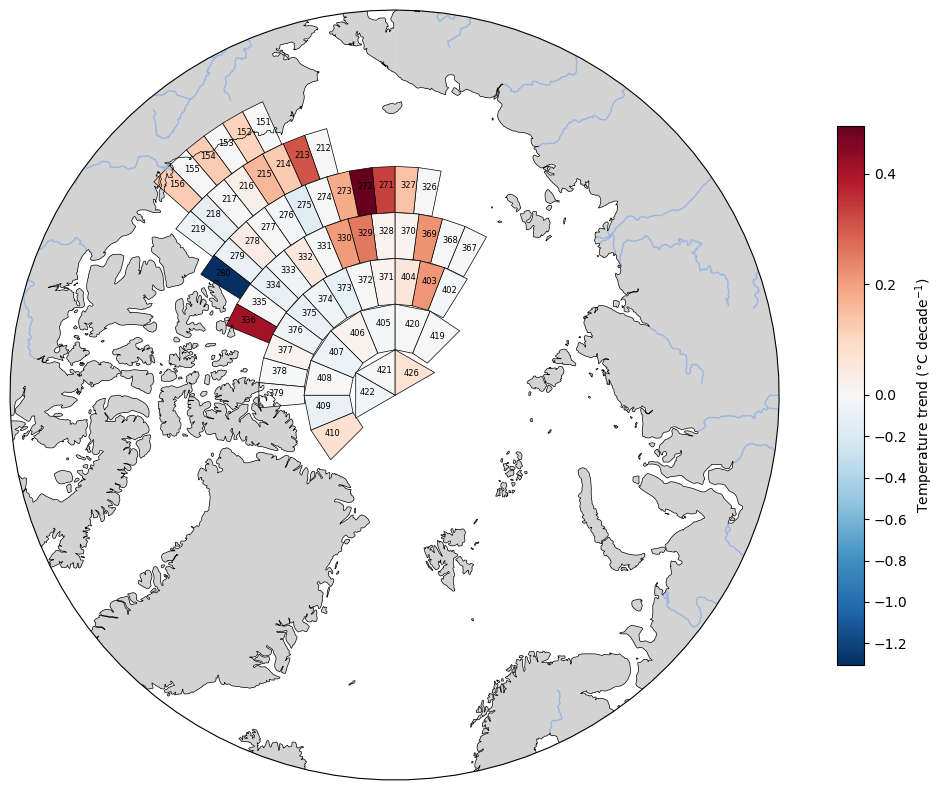

In [10]:
f, ax = plt.subplots(
    1, 1,
    figsize=[15,10],
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)
# ax=ax.ravel()
Atools.plot_arctic_ax_map_new(ax, gridlines=False)

from matplotlib.collections import PolyCollection
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

polys = []
values = []

cmap = plt.cm.RdBu_r
norm = colors.TwoSlopeNorm(vcenter=0)

for i in range(len(xc150)):

    if np.all(yc150[i] >= 65):

        val = slope_box_depth[i,7] * 10   # °C per decade

        if not np.isfinite(val):
            continue
        ax.text(np.mean(xc150[i]),
            np.mean(yc150[i]),
            box_id[i], fontsize=6, color='black',transform=ccrs.PlateCarree(),
           va='center',ha='center')

        polys.append(list(zip(xc150[i], yc150[i])))
        if pval_box_depth[i,7]<0.05:
            values.append(val)
        else:
            values.append(0)

collection = PolyCollection(
    polys,
    array=np.array(values),
    cmap=cmap,
    norm=norm,
    edgecolors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

ax.add_collection(collection)

cbar = plt.colorbar(collection, ax=ax, shrink=0.7)
cbar.set_label("Temperature trend (°C decade$^{-1}$)")

326


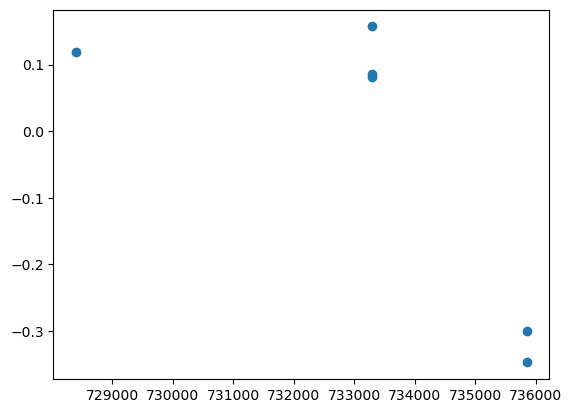

In [11]:
idx = 325
id_depth = 25
box_num = box_id[idx]
print(box_num)
prof_idx = profiles_in_box[box_num]

plt.scatter(ds_anom.time[prof_idx],ds_anom.temperature_QC_anom[prof_idx,id_depth])
# plt.scatter(ds_anom.time[prof_idx],ds_anom.temperature_QC_anom_dtd[prof_idx,id_depth])

Text(0.5, 0, 'Temperature trend (°C decade$^{-1}$)')

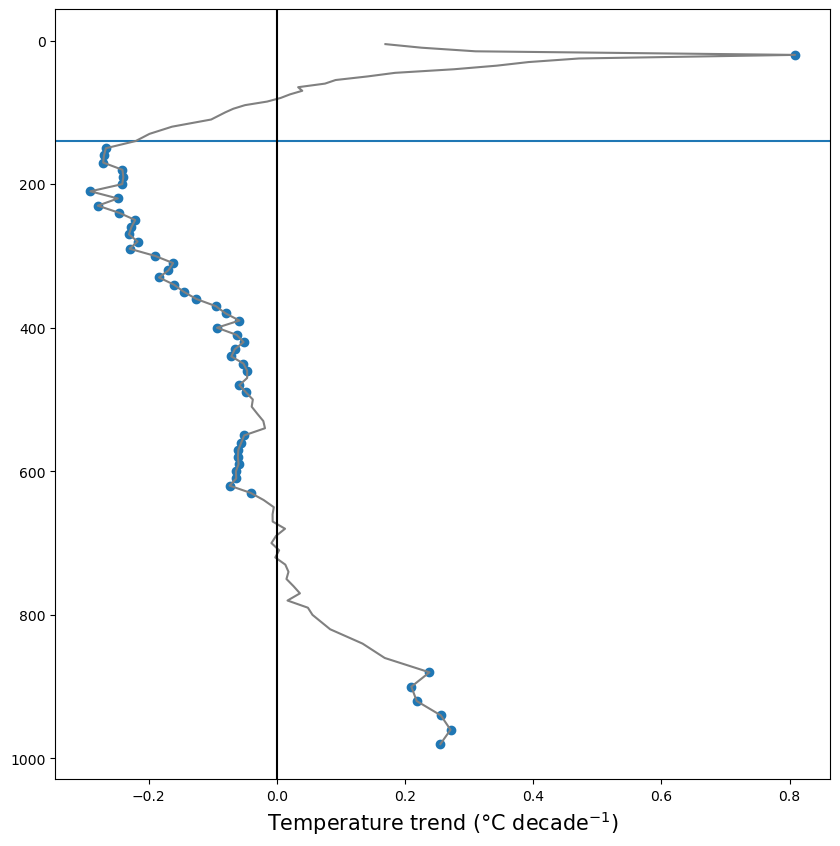

In [12]:
f,ax = plt.subplots(1,1,figsize=[10,10])
ftz=15
ax.axhline(ds_anom.depth[id_depth])
ax.plot(slope_box_depth[idx,:]*10,ds_anom.depth,color='grey')
mask = pval_box_depth[idx, :] < 0.05
ax.scatter(slope_box_depth[idx,mask]*10,ds_anom.depth[mask])
#ax.plot(slope_box_depth[420,:]*10,ds_anom.depth)
ax.invert_yaxis()
ax.axvline(0,color='black')
ax.set_xlabel("Temperature trend (°C decade$^{-1}$)",fontsize=ftz)

# Make seasonal means

In [20]:
ds_anom_test = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_detrended_relative_ISAS_amerasian.nc')

In [21]:
ds_jfm = ds_anom_test.sel(profile=ds_anom_test.time.dt.month.isin([1, 2, 3]))
ds_amj = ds_anom_test.sel(profile=ds_anom_test.time.dt.month.isin([4, 5, 6]))
ds_jas = ds_anom_test.sel(profile=ds_anom_test.time.dt.month.isin([7, 8, 9]))
ds_ond = ds_anom_test.sel(profile=ds_anom_test.time.dt.month.isin([10, 11, 12]))


ds_jfm['source'] = ds_jfm['source'].astype(str)
ds_amj['source'] = ds_amj['source'].astype(str)
ds_jas['source'] = ds_jas['source'].astype(str)
ds_ond['source'] = ds_ond['source'].astype(str)

In [22]:
ds_jfm.to_netcdf('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_detrended_relative_ISAS_amerasian_jfm.nc')
ds_amj.to_netcdf('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_detrended_relative_ISAS_amerasian_amj.nc')
ds_jas.to_netcdf('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_detrended_relative_ISAS_amerasian_jas.nc')
ds_ond.to_netcdf('/data0/user/aprigent/PROCESSED/level_4/temp_anomalies_detrended_relative_ISAS_amerasian_ond.nc')